# Qui uso il Firms NASA per fare la previsione di incendi sul territorio

## API per vedere la mia MAP_KEY per accedere ai dati via richieste API

In [6]:
# # Let's set your map key that was emailed to you. It should look something like 'abcdef1234567890abcdef1234567890'
# MAP_KEY = '<replace with your map_key>'
MAP_KEY = '2c5ba4423dded18d0b41241170c6d284'

# now let's check how many transactions we have
import pandas as pd
import requests
url = 'https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?MAP_KEY=' + MAP_KEY
try:
  response = requests.get(url)
  data = response.json()
  df = pd.Series(data)
  display(df)
except:
  # possible error, wrong MAP_KEY value, check for extra quotes, missing letters
  print ("There is an issue with the query. \nTry in your browser: %s" % url)

transaction_limit             5000
current_transactions             0
transaction_interval    10 minutes
dtype: object

## API per vedere i datasets

In [7]:
# let's query data_availability to find out what date range is available for various datasets
# we will explain these datasets a bit later

# this url will return information about all supported sensors and their corresponding datasets
# instead of 'all' you can specify individual sensor, ex:LANDSAT_NRT
da_url = 'https://firms.modaps.eosdis.nasa.gov/api/data_availability/csv/' + MAP_KEY + '/all'
df_datasets = pd.read_csv(da_url)
display(df_datasets)



,data_id,min_date,max_date
0,MODIS_NRT,2026-01-01,2026-04-20
1,MODIS_SP,2000-11-01,2025-12-31
2,VIIRS_NOAA20_NRT,2026-03-01,2026-04-20
3,VIIRS_NOAA20_SP,2018-04-01,2026-02-28
4,VIIRS_NOAA21_NRT,2024-01-17,2026-04-20
5,VIIRS_SNPP_NRT,2026-03-01,2026-04-20
6,VIIRS_SNPP_SP,2012-01-20,2026-02-28
7,LANDSAT_NRT,2022-06-20,2026-04-20
8,GOES_NRT,2022-08-09,2026-04-20
9,BA_MODIS,2000-11-01,2026-02-01


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)


fig, ax = plt.subplots(figsize=(14, 8))

world.plot(ax=ax, color="lightgrey", edgecolor="white")

gdf_hotspots.plot(
    column="score_hotspot",
    cmap="inferno",
    markersize=80,
    legend=True,
    ax=ax
)

ax.set_title("🔥 Hotspot Incendi Globali", fontsize=16)

plt.show()


ModuleNotFoundError: No module named 'geopandas'

In [19]:
import sys
print(sys.executable)


KeyboardInterrupt: 

## Script per salvare tutti i dataset per iterare sopra

In [10]:
datasets = []
for i in df_datasets["data_id"]:
    datasets.append(i)
print(datasets)

['MODIS_NRT', 'MODIS_SP', 'VIIRS_NOAA20_NRT', 'VIIRS_NOAA20_SP', 'VIIRS_NOAA21_NRT', 'VIIRS_SNPP_NRT', 'VIIRS_SNPP_SP', 'LANDSAT_NRT', 'GOES_NRT', 'BA_MODIS', 'BA_VIIRS']


## Data Ingest 

In [11]:
dfs = []

for dataset in datasets:
    area_url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{MAP_KEY}/{dataset}/world/1"
    df = pd.read_csv(area_url)
    df["dataset"] = dataset
    dfs.append(df)

df_finale = pd.concat(dfs, ignore_index=True)

C:\Users\claud\AppData\Local\Temp\ipykernel_28004\1911961161.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_finale = pd.concat(dfs, ignore_index=True)


In [12]:
df_finale.shape

(119345, 20)

In [13]:
df = df_finale.to_csv("dataset_incendi_FIRMS.csv", index=False)

In [14]:
# Bounding box Italia
df_italia = df_finale[
    (df_finale['longitude'] >= 6) &
    (df_finale['longitude'] <= 19) &
    (df_finale['latitude'] >= 36) &
    (df_finale['latitude'] <= 47)
].copy()

print(df_italia)

        latitude  longitude  brightness    scan    track    acq_date acq_time  \
2836    42.17234   13.83046      300.92    1.51     1.21  2026-04-20      850   
2837    42.17578   13.81255      301.47    1.51     1.21  2026-04-20      850   
2838    44.86591    8.80963      309.78    1.00     1.00  2026-04-20      850   
2839    45.35775   11.04725      307.34    1.05     1.02  2026-04-20      850   
2840    45.36648   10.87532      305.68    1.04     1.02  2026-04-20      850   
...          ...        ...         ...     ...      ...         ...      ...   
117981  38.38593   16.18816         NaN    0.00     0.00  2026-04-20     1628   
118610  38.38593   16.18816         NaN    0.00     0.00  2026-04-20     1638   
118627  37.54000   13.35000         NaN  647.00  1010.00  2026-04-20     1639   
119036  38.37262   16.18469         NaN    0.00     0.00  2026-04-20     1648   
119037  38.38593   16.18816         NaN    0.00     0.00  2026-04-20     1648   

       satellite instrument

In [15]:
df_italia.shape

(273, 20)

In [16]:
import pandas as pd

df = pd.read_csv("dataset_incendi_FIRMS.csv") 

C:\Users\claud\AppData\Local\Temp\ipykernel_28004\362926041.py:3: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset_incendi_FIRMS.csv")


In [17]:
df_italia = df_finale[
    (df_finale['longitude'] >= 6) &
    (df_finale['longitude'] <= 19) &
    (df_finale['latitude'] >= 36) &
    (df_finale['latitude'] <= 47)
].copy()

In [18]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

ModuleNotFoundError: No module named 'geopandas'

In [ ]:
gdf.plot(column='brightness', figsize=(10, 6), legend=True, markersize=2)

In [ ]:
from IPython.display import display

m = gdf.explore(column="brightness", legend=True)

   Fatto ✓


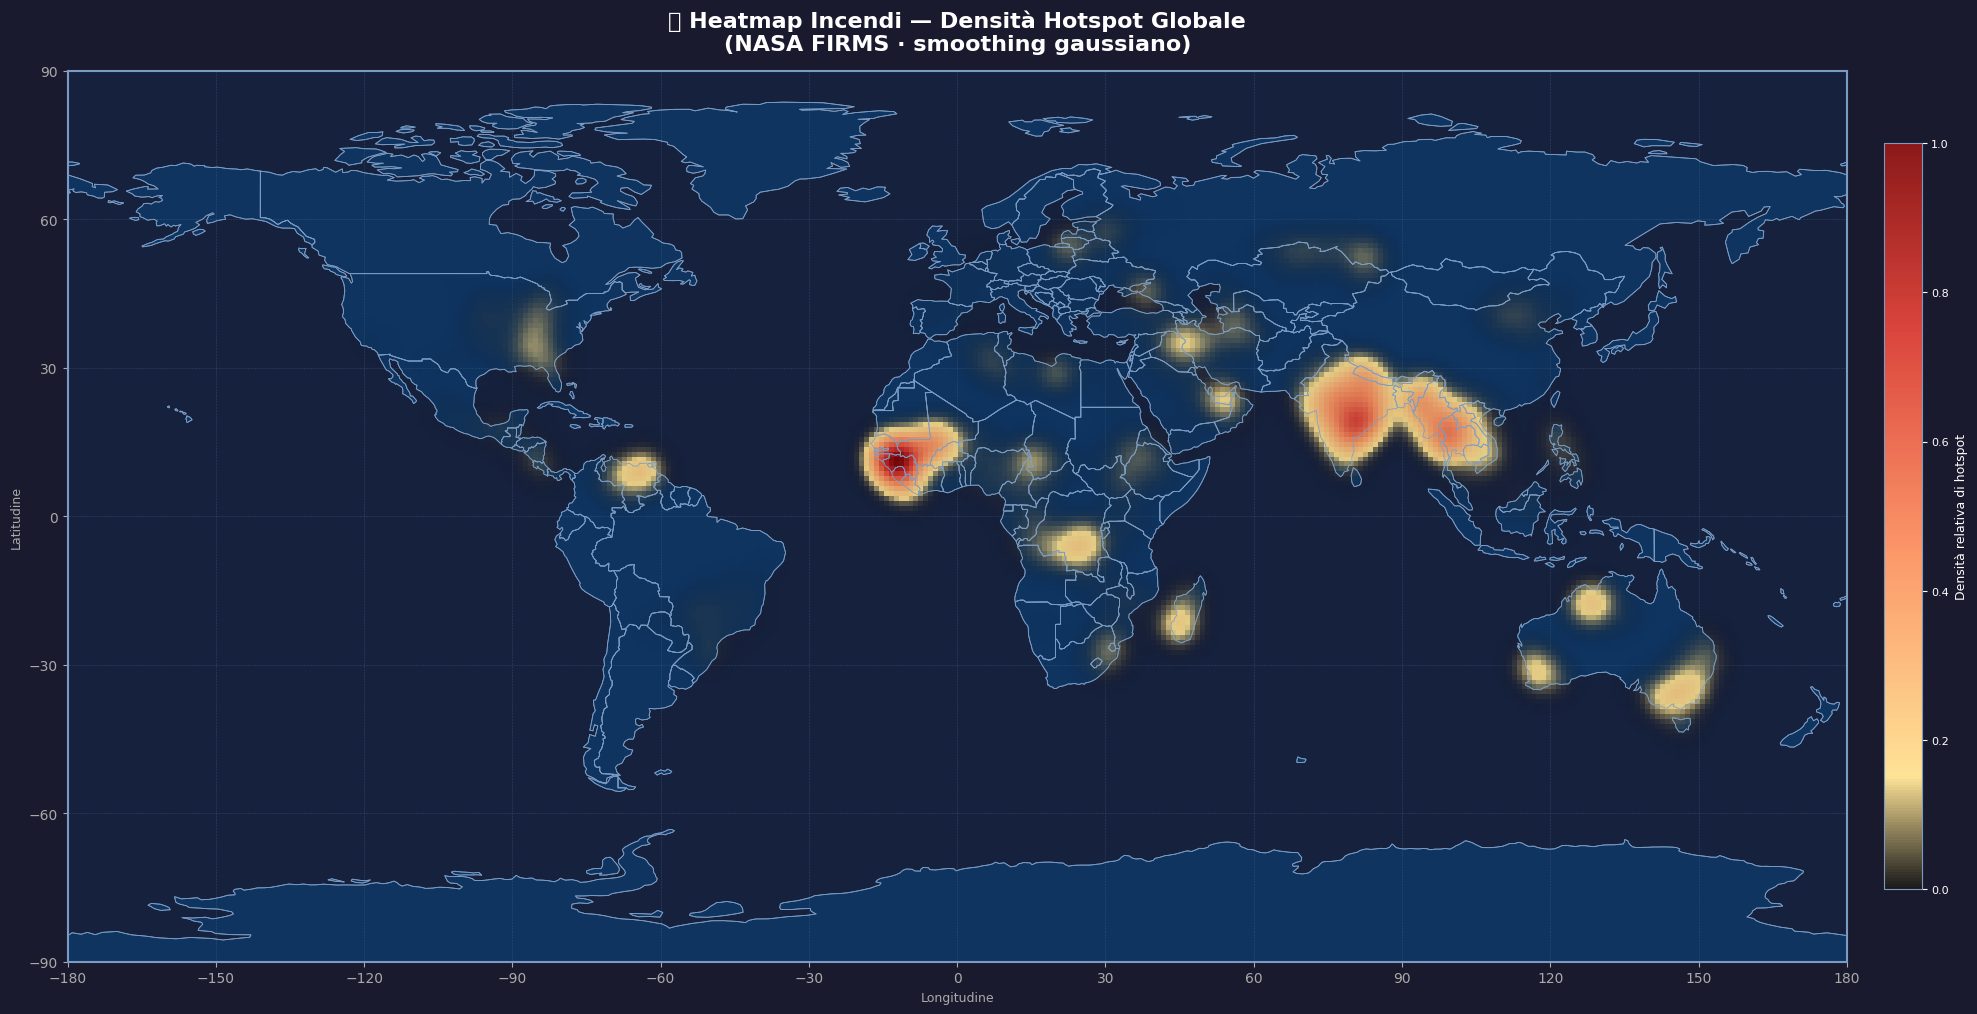

<Figure size 640x480 with 0 Axes>

In [ ]:
## flusso degli incendi
%matplotlib inline
%run areeCalde.py

📂 Carico il dataset...
Range: 2026-04-20 → 2026-04-20


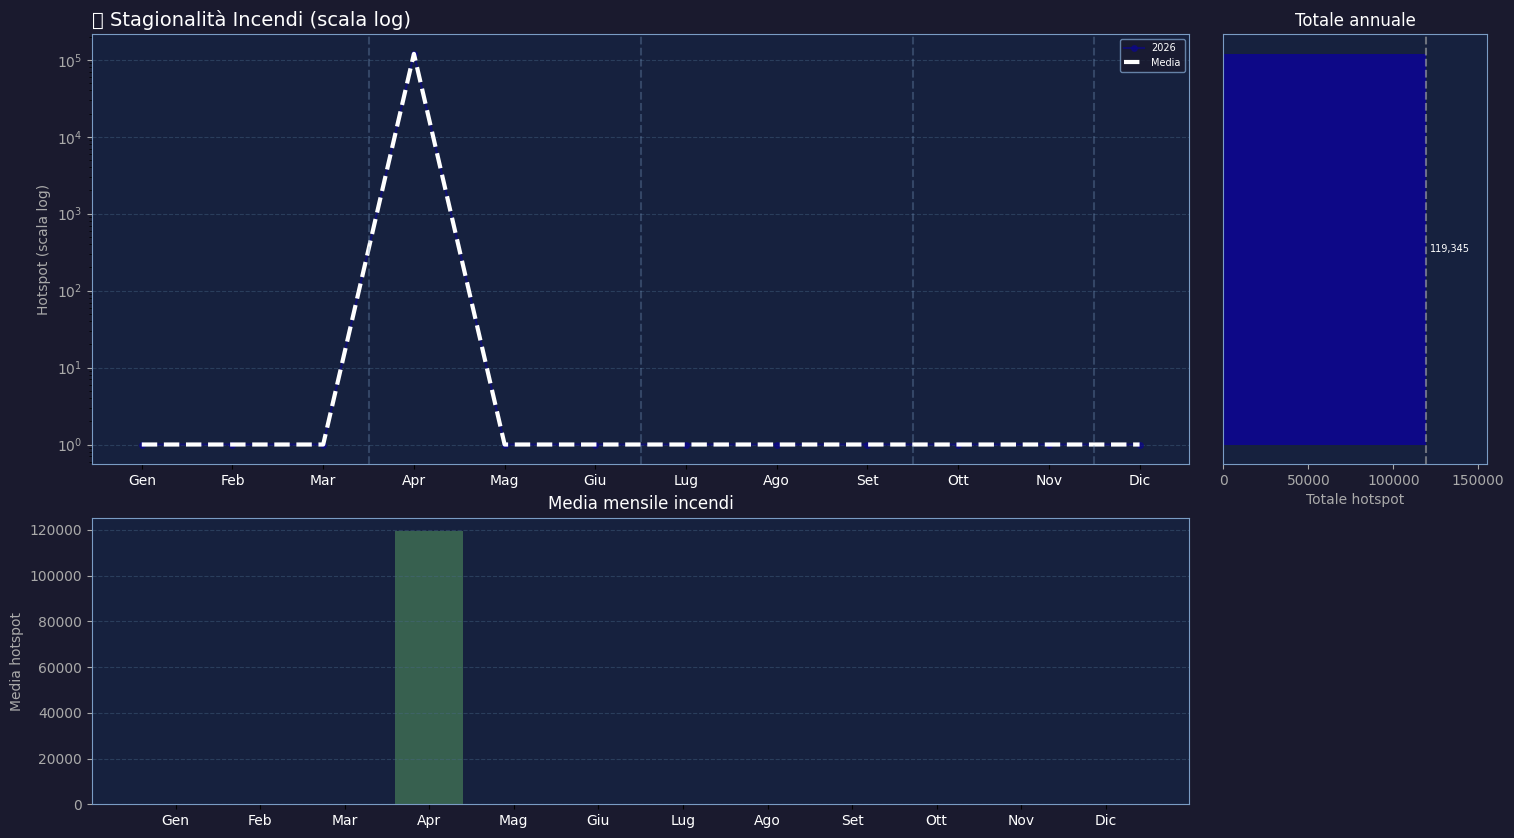

<Figure size 640x480 with 0 Axes>

In [9]:
## Stagionalità degli Incendi
%matplotlib inline
%run stagionalita.py